In [1]:
from pathlib import Path
import xarray as xr
import ecco_v4_py as ecco
from xgcm import Grid
import gsw
import matplotlib.pyplot as plt
import cmocean
import numpy as np
from scipy.interpolate import interp1d
from scipy import optimize
import pandas as pd
import matplotlib.dates as mdates
from os.path import join,expanduser,exists,split
import glob

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
plt.rcParams['figure.figsize'] = (10, 6)

#### **Load the desired variables and define grid/metrics**

In [4]:
ECCO_version = 'v4r4'
#ECCO_version = 'v4r5'

if ECCO_version == 'v4r4':
    # v4r4
    ECCO_dir = Path.home() / 'share_disk3/ECCO_products/Version4/Release4'
    grid_file_path = glob.glob(join(ECCO_dir,'*GEOMETRY*','*GEOMETRY*.nc'))[0]
    TS_file_paths           = join(ECCO_dir,'*TEMP_SALINITY*MONTHLY*',f'*.nc')
else: # by default
    ## v4r5
    ECCO_version = 'v4r5'
    ECCO_grid = Path.home() / 'share_disk3/ECCO_products/Version4/Release5/netcdf/native/grid/'
    ECCO_dir = Path.home() / 'share_disk3/ECCO_products/Version4/Release5/netcdf/native/monthly/'
    grid_file_path = glob.glob(join(ECCO_grid,'*GEOMETRY*.nc'))[0]
    TS_file_paths           = join(ECCO_dir,'*TEMPERATURE_SALINITY',f'*.nc')
print(ECCO_version)

v4r4


In [5]:
## Load the model grid
ecco_grid = xr.open_mfdataset(grid_file_path,\
                              chunks={'k':50,'tile':13,'j':90,'j_g':90,'i':90,'i_g':90})

In [6]:
## Create a dataset of monthly advective and diffusive temperature fluxes, 1992-2017
ecco_vars_ts = xr.open_mfdataset(TS_file_paths,\
                              chunks={'k':50,'tile':13,'j':90,'j_g':90,'i':90,'i_g':90},\
                              parallel=True,data_vars='minimal',coords='minimal',compat='override')

In [7]:
## Merge the ecco_grid with the ecco_vars to make the ecco_ds
ecco_ds = xr.merge((ecco_grid , ecco_vars_ts),compat='override')

In [8]:
# define the metrics
ecco_ds['drW'] = ecco_ds.hFacW * ecco_ds.drF #vertical cell size at u point
ecco_ds['drS'] = ecco_ds.hFacS * ecco_ds.drF #vertical cell size at v point
ecco_ds['drV'] = ecco_ds.rA * ecco_ds.drF # volume at centre and k
ecco_ds['drVg'] = ecco_ds.rAz * ecco_ds.drF # volume at q and k
ecco_ds['drVw'] = ecco_ds.rAw * ecco_ds.drF # volume at q and k
ecco_ds['drVs'] = ecco_ds.rAs * ecco_ds.drF # volume at q and k

metrics = { ('X',): ['dxC', 'dxG'], # X distances
    ('Y',): ['dyC', 'dyG'], # Y distances
    ('Z',): ['drW', 'drS', 'drC','drF'], # Z distances
    ('X', 'Y'): ['rA', 'rAz', 'rAs', 'rAw'], #Areas
    ('X', 'Y','Z'): ['drV','drVg','drVs','drVw']} #volumes

grid = Grid(ecco_ds,periodic=False, metrics=metrics)

In [9]:
g = 9.81
rho0=1026

#### **Compute partial mean-$N^2$ and $D_{COM}$ over different depths**

#### $$ N^2 = -g \alpha \frac{d\Theta}{dz} + g \beta \frac{dS}{dz} $$
#### $$ D_{COM} = \frac{1}{g} \left< h_{d}^{z_v}(S, \Theta, z) - h_{d}^{z_v}(\left<S\right>, \left<\Theta\right>, z) \right> $$


Time-Average below a given depth H, before computing stratification index 

In [14]:
df = pd.read_csv(f'volumes_per_depth_ECCO{ECCO_version}.csv').set_index('depth')

In [15]:
columns = ['time','depth','N2_mean','CoM']
df = pd.DataFrame(columns=columns)

SALT_timemean = ecco_ds.SALT.mean('time').compute()
THETA_timemean = ecco_ds.THETA.mean('time').compute()

for depth,depthu in zip(-ecco_ds.Z.values,-ecco_ds.Zu.values):
    
    maskC = ecco_ds.maskC
    volume = grid.integrate(maskC,['X','Y','Z']).sum('tile').compute()
    
    # partial averaging
    SALT_timemean_belowH = ecco_ds.SALT.where(ecco_ds.Z>=-depth,SALT_timemean)
    THETA_timemean_belowH = ecco_ds.THETA.where(ecco_ds.Z>=-depth,THETA_timemean)
    
    # mean-N2
    print(f'Now doing 0 - {np.floor(depthu)} m: N2_mean')
    maskW = (grid.diff(ecco_ds.maskC.astype(float),'Z',to='outer',boundary='extend')+1)
    alpha = gsw.alpha(SALT_timemean_belowH,THETA_timemean_belowH,-ecco_ds.Z)
    beta  = gsw.beta (SALT_timemean_belowH,THETA_timemean_belowH,-ecco_ds.Z)
    N2_T = -g*alpha*grid.interp(grid.derivative(THETA_timemean_belowH,'Z',to='outer',boundary='extend')*maskW , 'Z') * ecco_ds.maskC     #Interpolate again to get back on center point Z
    N2_S =  g*beta *grid.interp(grid.derivative(SALT_timemean_belowH ,'Z',to='outer',boundary='extend')*maskW , 'Z') * ecco_ds.maskC
    N2   = N2_T + N2_S
    N2_mean = grid.integrate( N2*maskC , ['X','Y','Z']).sum('tile') / volume
    N2_mean = N2_mean.compute()

    # CoM
    print(f'Now doing 0 - {np.floor(depthu)} m: zg_mean')
    centre_volume = grid.integrate(ecco_ds.Z*maskC ,['X','Y','Z']).sum('tile') / volume
    h0    = gsw.dynamic_enthalpy(SALT_timemean_belowH,THETA_timemean_belowH,-ecco_ds.Z)
    h0_zv = gsw.dynamic_enthalpy(SALT_timemean_belowH,THETA_timemean_belowH,-centre_volume)
    h_zv  = h0 - h0_zv
    mean_THETA = grid.integrate(THETA_timemean_belowH*maskC,['X','Y','Z']).sum('tile').compute() / volume
    mean_SALT  = grid.integrate(SALT_timemean_belowH *maskC,['X','Y','Z']).sum('tile').compute() / volume
    h0_0    = gsw.dynamic_enthalpy(ecco_ds.SALT*0+mean_SALT,mean_THETA, -ecco_ds.Z)
    h0_zv_0 = gsw.dynamic_enthalpy(ecco_ds.SALT*0+mean_SALT,mean_THETA, -centre_volume)
    h_zv_0  = h0_0 - h0_zv_0
    zg = - grid.integrate( (h_zv - h_zv_0)*maskC/g, ['X','Y','Z']).sum('tile') / volume
    zg = zg.compute()

    for index,time in enumerate(ecco_ds.time.values):
        df.loc[len(df)] = [time,np.floor(depthu),N2_mean.values[index],zg.values[index]]

df.to_csv(f'N2_D_COM_partial_mean_ECCO{ECCO_version}.csv',index=False)

Now doing 0 - 10.0 m: N2_mean
Now doing 0 - 10.0 m: zg_mean
Now doing 0 - 20.0 m: N2_mean
Now doing 0 - 20.0 m: zg_mean
Now doing 0 - 30.0 m: N2_mean
Now doing 0 - 30.0 m: zg_mean
Now doing 0 - 40.0 m: N2_mean
Now doing 0 - 40.0 m: zg_mean
Now doing 0 - 50.0 m: N2_mean
Now doing 0 - 50.0 m: zg_mean
Now doing 0 - 60.0 m: N2_mean
Now doing 0 - 60.0 m: zg_mean
Now doing 0 - 70.0 m: N2_mean
Now doing 0 - 70.0 m: zg_mean
Now doing 0 - 80.0 m: N2_mean
Now doing 0 - 80.0 m: zg_mean
Now doing 0 - 90.0 m: N2_mean
Now doing 0 - 90.0 m: zg_mean
Now doing 0 - 100.0 m: N2_mean
Now doing 0 - 100.0 m: zg_mean
Now doing 0 - 110.0 m: N2_mean
Now doing 0 - 110.0 m: zg_mean
Now doing 0 - 121.0 m: N2_mean
Now doing 0 - 121.0 m: zg_mean
Now doing 0 - 133.0 m: N2_mean
Now doing 0 - 133.0 m: zg_mean
Now doing 0 - 146.0 m: N2_mean
Now doing 0 - 146.0 m: zg_mean
Now doing 0 - 162.0 m: N2_mean
Now doing 0 - 162.0 m: zg_mean
Now doing 0 - 182.0 m: N2_mean
Now doing 0 - 182.0 m: zg_mean
Now doing 0 - 207.0 m: N2_

In [16]:
df = pd.read_csv(f'N2_D_COM_partial_mean_ECCO{ECCO_version}.csv',index_col=None,parse_dates=["time"])
df = df.set_index(['time','depth'])

<Axes: xlabel='time'>

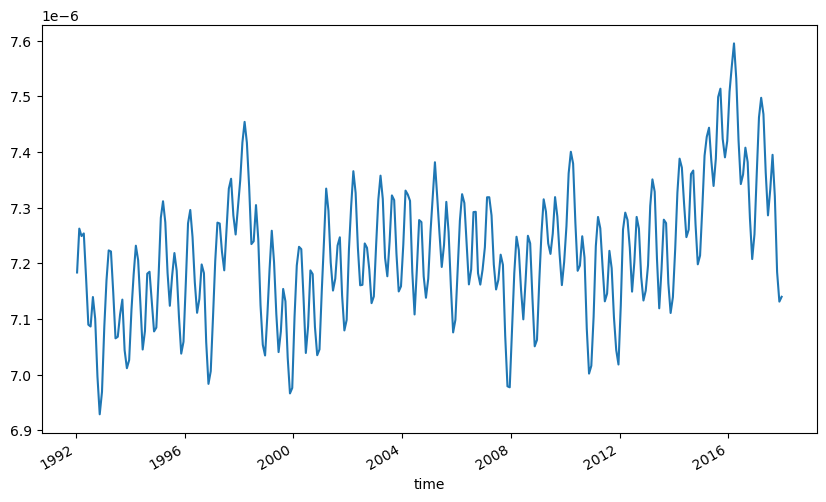

In [17]:
df.xs(6134, level=1).N2_mean.plot()

<Axes: xlabel='time'>

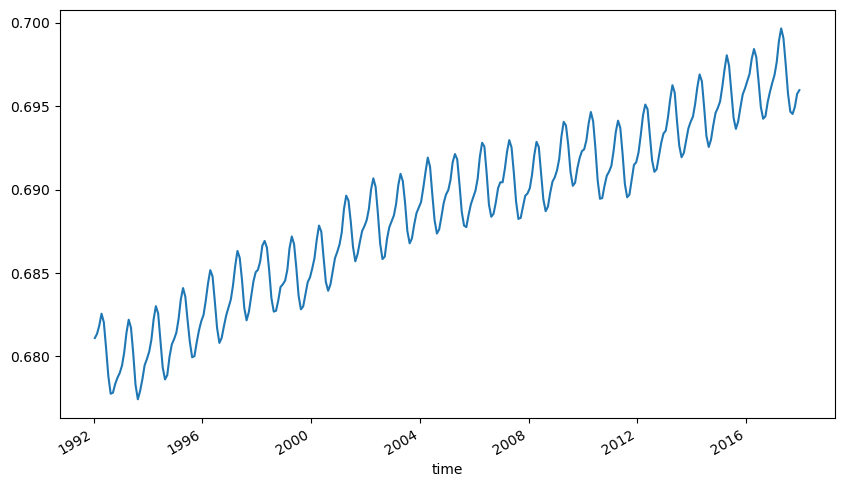

In [18]:
df.xs(6134, level=1).CoM.plot()